In [1]:
# ============================================
# PROJECT 2: Late Delivery Risk Prediction
# Phase 8: Detailed Model Evaluation
# Author: Mohan | Unified Mentor Internship
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import joblib

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load test data
X_test = joblib.load('../models/X_test_scaled.pkl')
y_test = joblib.load('../models/y_test.pkl')
feature_names = joblib.load('../models/feature_names.pkl')

# Load all 3 trained models
lr_model = joblib.load('../models/model_logistic_regression.pkl')
rf_model = joblib.load('../models/model_random_forest.pkl')
xgb_model = joblib.load('../models/model_xgboost.pkl')
best_model = joblib.load('../models/best_model.pkl')

with open('../models/best_model_name.txt', 'r') as f:
    best_model_name = f.read().strip()

print("✅ All models loaded successfully!")
print(f"🏆 Best Model: {best_model_name}")
print(f"📊 Test set size: {X_test.shape[0]:,} samples")

✅ All models loaded successfully!
🏆 Best Model: XGBoost
📊 Test set size: 36,104 samples


In [2]:
# ===== GENERATE PREDICTIONS FOR ALL MODELS =====

models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]
    print(f"✅ Predictions generated for {name}")

print(f"\n📊 Total predictions per model: {len(predictions['XGBoost']):,}")

✅ Predictions generated for Logistic Regression
✅ Predictions generated for Random Forest
✅ Predictions generated for XGBoost

📊 Total predictions per model: 36,104


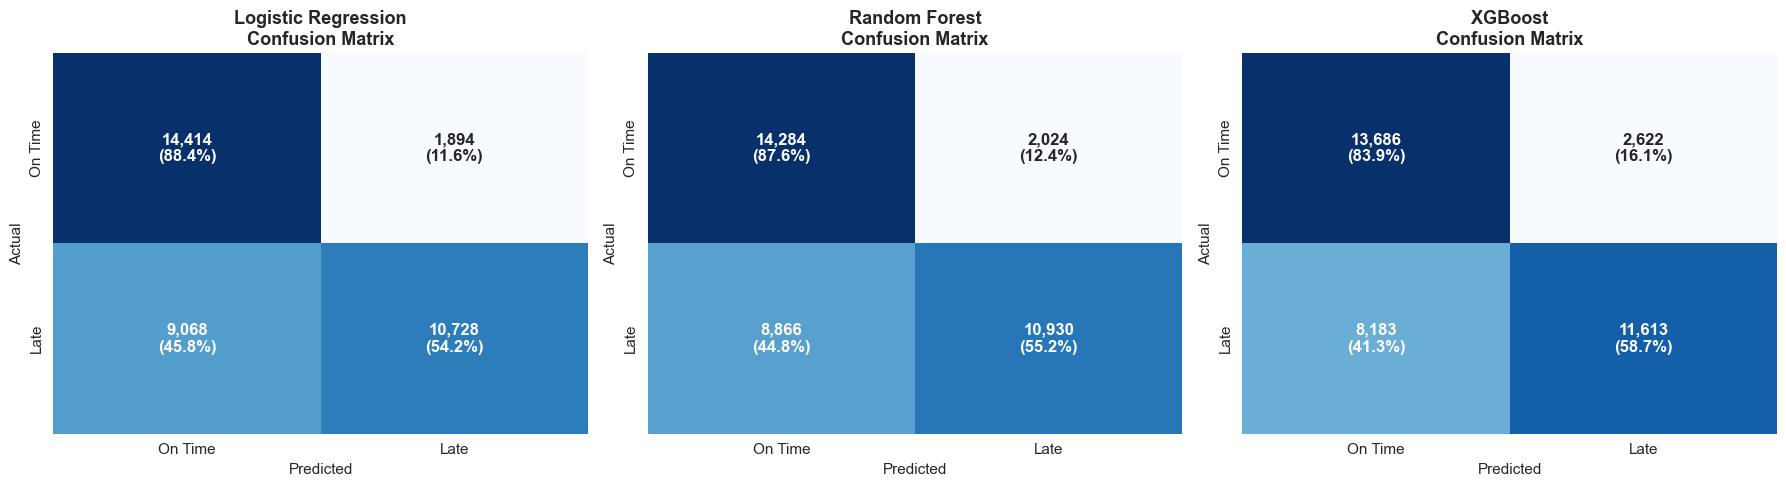


✅ Chart saved: charts/18_confusion_matrices.png


In [3]:
# ===== CONFUSION MATRICES FOR ALL MODELS =====
# A confusion matrix shows: TN, FP, FN, TP
#   TN = Predicted On-Time, Actually On-Time   (correct)
#   FP = Predicted Late, Actually On-Time      (false alarm)
#   FN = Predicted On-Time, Actually Late      (MISSED — costly!)
#   TP = Predicted Late, Actually Late         (correct catch)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    # Calculate percentages for context
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create annotation strings with both count and percentage
    annot = np.array([[f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)' 
                        for j in range(2)] for i in range(2)])
    
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=['On Time', 'Late'],
                yticklabels=['On Time', 'Late'],
                ax=ax, cbar=False, annot_kws={'size': 12, 'fontweight': 'bold'})
    
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('../charts/18_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved: charts/18_confusion_matrices.png")

In [4]:
# ===== CLASSIFICATION REPORTS FOR ALL MODELS =====
# More detailed metrics per class

for name, y_pred in predictions.items():
    print(f"\n{'='*60}")
    print(f"CLASSIFICATION REPORT: {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, 
                                  target_names=['On Time (0)', 'Late (1)'],
                                  digits=4))


CLASSIFICATION REPORT: Logistic Regression
              precision    recall  f1-score   support

 On Time (0)     0.6138    0.8839    0.7245     16308
    Late (1)     0.8499    0.5419    0.6619     19796

    accuracy                         0.6964     36104
   macro avg     0.7319    0.7129    0.6932     36104
weighted avg     0.7433    0.6964    0.6902     36104


CLASSIFICATION REPORT: Random Forest
              precision    recall  f1-score   support

 On Time (0)     0.6170    0.8759    0.7240     16308
    Late (1)     0.8438    0.5521    0.6675     19796

    accuracy                         0.6984     36104
   macro avg     0.7304    0.7140    0.6957     36104
weighted avg     0.7413    0.6984    0.6930     36104


CLASSIFICATION REPORT: XGBoost
              precision    recall  f1-score   support

 On Time (0)     0.6258    0.8392    0.7170     16308
    Late (1)     0.8158    0.5866    0.6825     19796

    accuracy                         0.7007     36104
   macro avg  

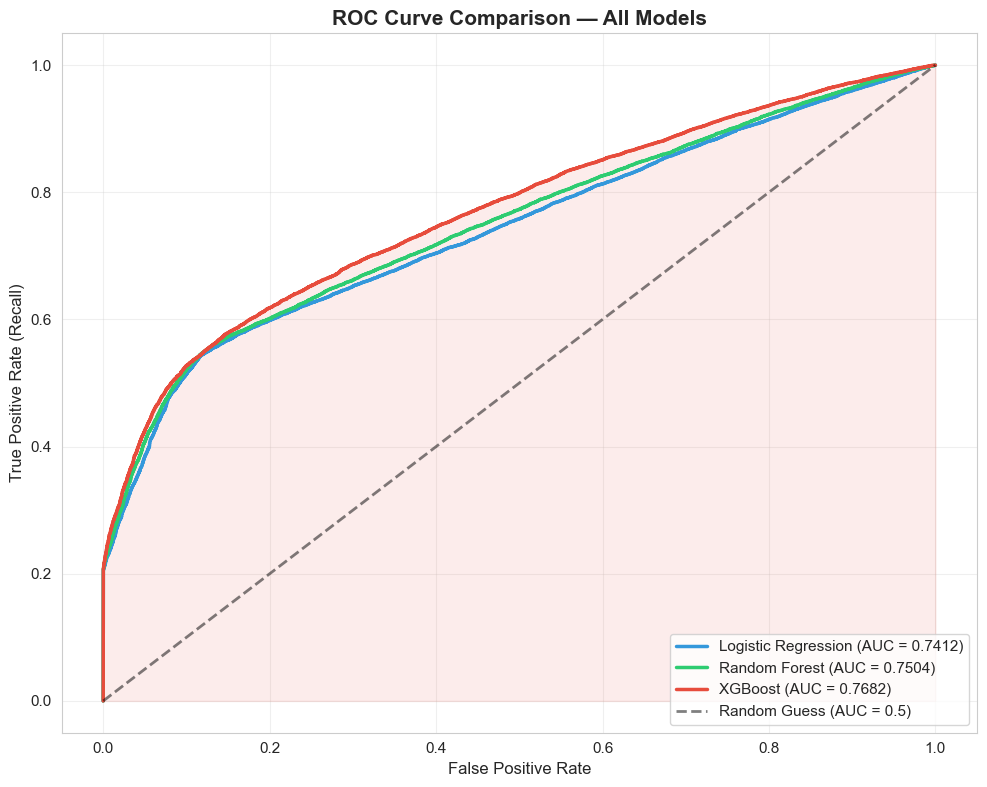


✅ Chart saved: charts/19_roc_curves.png

💡 The curve closest to top-left corner is the best model.


In [5]:
# ===== ROC CURVES =====
# ROC = Receiver Operating Characteristic
# X-axis: False Positive Rate (false alarms)
# Y-axis: True Positive Rate (real catches)
# Better model = curve closer to top-left corner
# AUC = Area Under Curve (1.0 = perfect, 0.5 = random)

fig, ax = plt.subplots(figsize=(10, 8))

colors = {'Logistic Regression': '#3498db', 
          'Random Forest': '#2ecc71', 
          'XGBoost': '#e74c3c'}

for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, lw=2.5, color=colors[name],
            label=f'{name} (AUC = {roc_auc:.4f})')

# Random guess baseline
ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Random Guess (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve Comparison — All Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

# Shade the area under the best model for emphasis
best_proba = probabilities[best_model_name]
fpr_best, tpr_best, _ = roc_curve(y_test, best_proba)
ax.fill_between(fpr_best, 0, tpr_best, alpha=0.1, color=colors[best_model_name])

plt.tight_layout()
plt.savefig('../charts/19_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved: charts/19_roc_curves.png")
print(f"\n💡 The curve closest to top-left corner is the best model.")

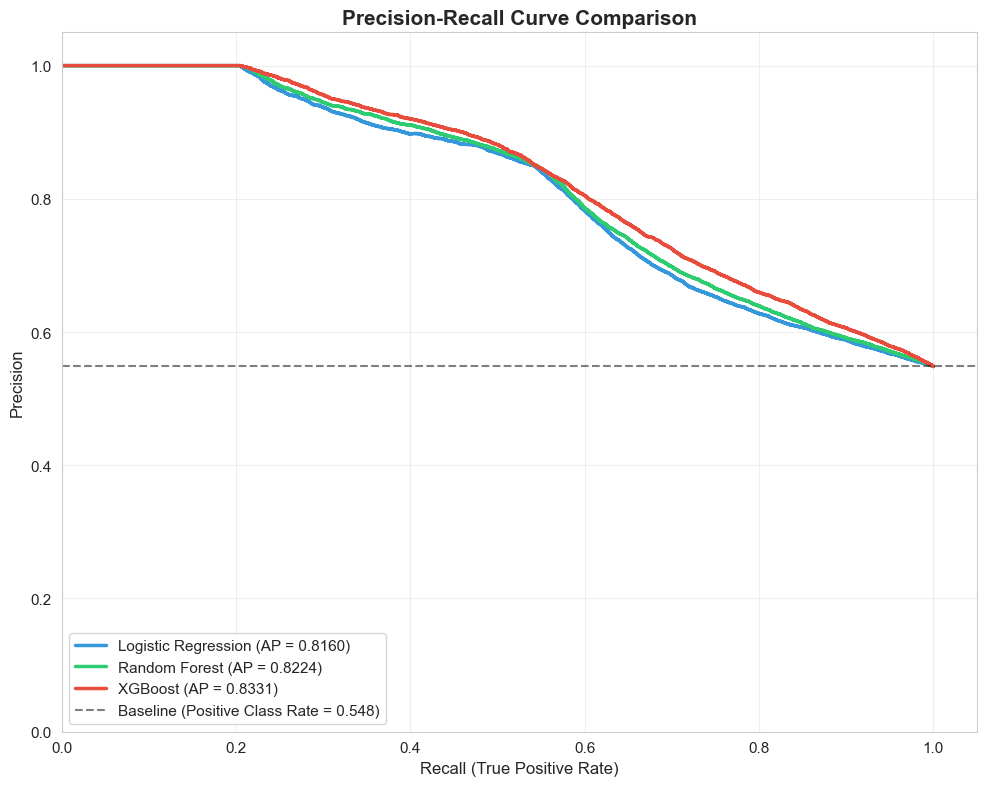


✅ Chart saved: charts/20_precision_recall_curves.png


In [6]:
# ===== PRECISION-RECALL CURVES =====
# PR curves are better than ROC for imbalanced data
# Higher curve = better

fig, ax = plt.subplots(figsize=(10, 8))

for name, y_proba in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)
    
    ax.plot(recall, precision, lw=2.5, color=colors[name],
            label=f'{name} (AP = {avg_precision:.4f})')

# Baseline (proportion of positive class)
baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5,
           label=f'Baseline (Positive Class Rate = {baseline:.3f})')

ax.set_xlabel('Recall (True Positive Rate)', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve Comparison', fontsize=15, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1.05])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('../charts/20_precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved: charts/20_precision_recall_curves.png")

📊 TOP 15 MOST IMPORTANT FEATURES (XGBoost):
                      Feature  Importance
              Mode_Risk_Score    0.573162
Days for shipment (scheduled)    0.107286
          Is_Transfer_Payment    0.041734
           Payment_Risk_Score    0.041672
           Segment_Risk_Score    0.020014
              Is_Express_Mode    0.019068
            Discount_Severity    0.016589
            Market_Risk_Score    0.015678
        Department_Risk_Score    0.012176
     Order Item Discount Rate    0.010888
     Order Item Product Price    0.009358
            Region_Risk_Score    0.009080
               Sales_Category    0.008272
          Category_Risk_Score    0.007684
                    Longitude    0.007634


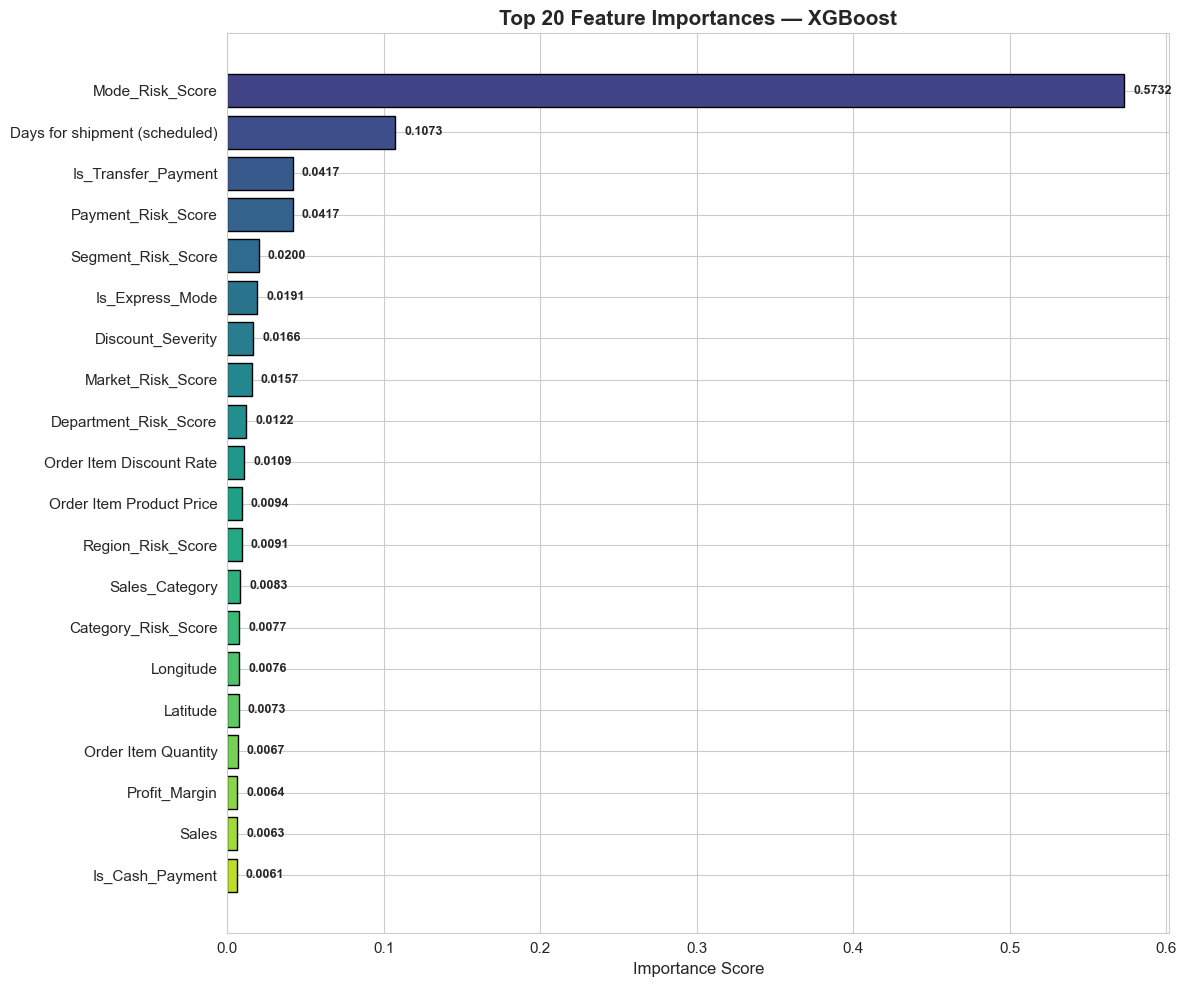


✅ Chart saved: charts/21_feature_importance.png

💡 KEY INSIGHT: Features at top are what the model relies on most.


In [7]:
# ===== FEATURE IMPORTANCE FROM BEST MODEL =====
# Shows WHICH features matter most for predictions
# This is the "explainability" the project requires

# Get feature importance based on model type
if best_model_name in ['Random Forest', 'XGBoost']:
    # Tree-based models have .feature_importances_
    importances = best_model.feature_importances_
else:
    # Logistic Regression — use absolute coefficient values
    importances = np.abs(best_model.coef_[0])

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f"📊 TOP 15 MOST IMPORTANT FEATURES ({best_model_name}):")
print("="*60)
print(importance_df.head(15).to_string(index=False))

# Visualize top 20
top_n = 20
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(12, 10))
colors_gradient = plt.cm.viridis(np.linspace(0.2, 0.9, top_n))

ax.barh(top_features['Feature'], top_features['Importance'], 
        color=colors_gradient, edgecolor='black')
ax.set_title(f'Top {top_n} Feature Importances — {best_model_name}', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.invert_yaxis()

for i, (feat, imp) in enumerate(zip(top_features['Feature'], top_features['Importance'])):
    ax.text(imp + max(top_features['Importance'])*0.01, i, 
            f'{imp:.4f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../charts/21_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart saved: charts/21_feature_importance.png")
print(f"\n💡 KEY INSIGHT: Features at top are what the model relies on most.")

In [8]:
# ===== HOW WELL DO RISK CATEGORIES SEPARATE TRUE/FALSE =====
# Validate our Low/Medium/High thresholds

best_proba = probabilities[best_model_name]

# Define risk categories
def categorize_risk(prob):
    if prob < 0.40:
        return 'Low Risk'
    elif prob < 0.70:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_categories = pd.Series(best_proba).apply(categorize_risk)

# Build summary table
risk_summary = pd.DataFrame({
    'Risk_Category': risk_categories.values,
    'Actual_Late': y_test.values
})

summary_table = risk_summary.groupby('Risk_Category').agg(
    Orders=('Actual_Late', 'count'),
    Actual_Late=('Actual_Late', 'sum'),
    Actual_Late_Rate=('Actual_Late', 'mean')
).reindex(['Low Risk', 'Medium Risk', 'High Risk'])

summary_table['Actual_Late_Rate'] = (summary_table['Actual_Late_Rate'] * 100).round(2)
summary_table['On_Time'] = summary_table['Orders'] - summary_table['Actual_Late']

print("="*65)
print("RISK CATEGORY VALIDATION")
print("="*65)
print(summary_table)

print(f"\n💡 INTERPRETATION:")
print(f"   • Low Risk:    Should have lowest actual late rate")
print(f"   • Medium Risk: Should have moderate late rate")
print(f"   • High Risk:   Should have highest actual late rate")
print(f"\n✅ If true → risk categories are well-calibrated for operations!")

RISK CATEGORY VALIDATION
               Orders  Actual_Late  Actual_Late_Rate  On_Time
Risk_Category                                                
Low Risk        15007         5117             34.10     9890
Medium Risk     10011         4882             48.77     5129
High Risk       11086         9797             88.37     1289

💡 INTERPRETATION:
   • Low Risk:    Should have lowest actual late rate
   • Medium Risk: Should have moderate late rate
   • High Risk:   Should have highest actual late rate

✅ If true → risk categories are well-calibrated for operations!


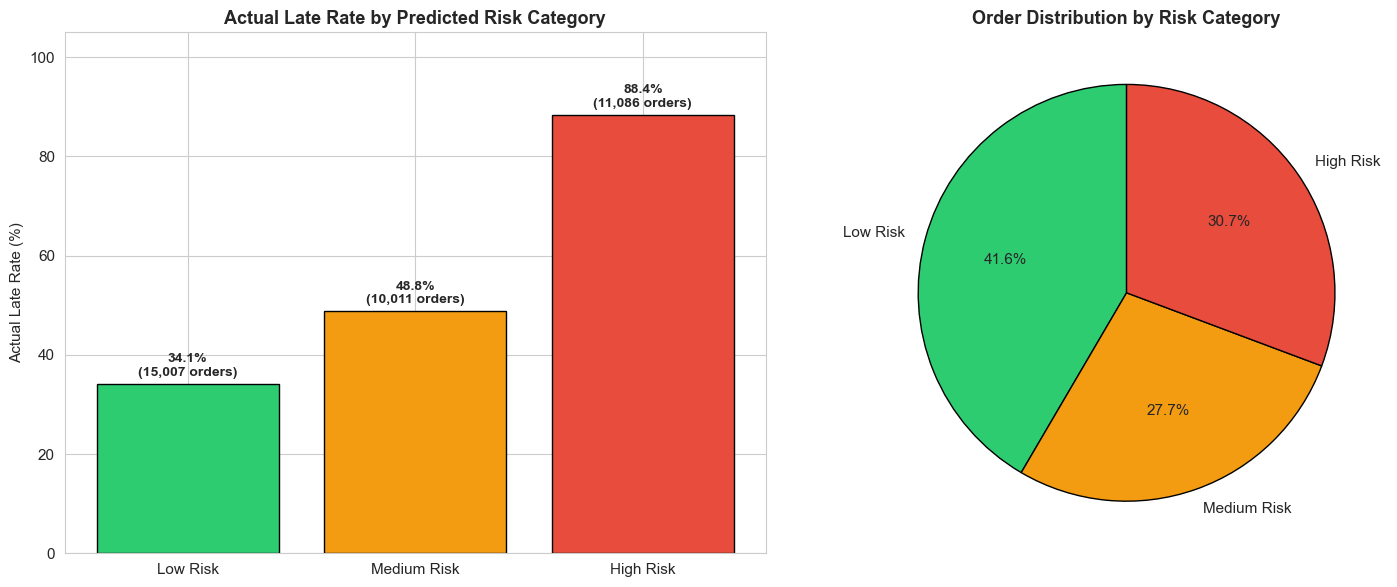


✅ Chart saved: charts/22_risk_validation.png


In [9]:
# ===== VISUALIZE RISK CATEGORY VALIDATION =====

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Actual late rate by risk category
risk_order = ['Low Risk', 'Medium Risk', 'High Risk']
colors_risk = ['#2ecc71', '#f39c12', '#e74c3c']

bars = axes[0].bar(summary_table.index, summary_table['Actual_Late_Rate'],
                    color=colors_risk, edgecolor='black')
axes[0].set_title('Actual Late Rate by Predicted Risk Category', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Late Rate (%)')
axes[0].set_ylim(0, 105)

for bar, value, count in zip(bars, summary_table['Actual_Late_Rate'], summary_table['Orders']):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 1,
                  f'{value:.1f}%\n({count:,} orders)',
                  ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2: Order distribution
axes[1].pie(summary_table['Orders'], labels=summary_table.index,
            colors=colors_risk, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Order Distribution by Risk Category', 
                   fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/22_risk_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved: charts/22_risk_validation.png")

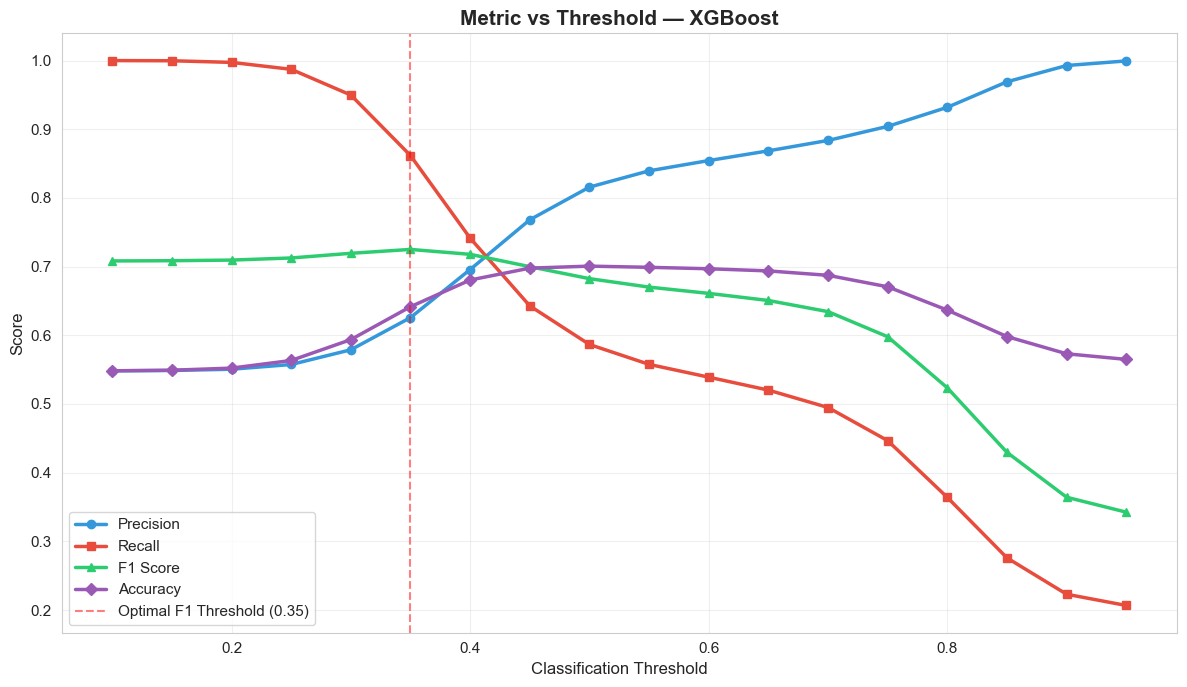


✅ Chart saved: charts/23_threshold_analysis.png

💡 OPTIMAL F1 THRESHOLD: 0.35
   At this threshold:
   - Precision: 0.6258
   - Recall:    0.8617
   - F1 Score:  0.7251


In [10]:
# ===== THRESHOLD SENSITIVITY ANALYSIS =====
# Default threshold is 0.5
# But for business, we might want different thresholds
# Show how Precision/Recall/F1 change at different thresholds

thresholds = np.arange(0.1, 1.0, 0.05)
threshold_results = []

best_proba = probabilities[best_model_name]

for thresh in thresholds:
    y_pred_thresh = (best_proba >= thresh).astype(int)
    threshold_results.append({
        'Threshold': thresh,
        'Precision': precision_score(y_test, y_pred_thresh, zero_division=0),
        'Recall': recall_score(y_test, y_pred_thresh, zero_division=0),
        'F1': f1_score(y_test, y_pred_thresh, zero_division=0),
        'Accuracy': accuracy_score(y_test, y_pred_thresh)
    })

threshold_df = pd.DataFrame(threshold_results)

# Visualize
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(threshold_df['Threshold'], threshold_df['Precision'], 
        marker='o', lw=2.5, label='Precision', color='#3498db')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'], 
        marker='s', lw=2.5, label='Recall', color='#e74c3c')
ax.plot(threshold_df['Threshold'], threshold_df['F1'], 
        marker='^', lw=2.5, label='F1 Score', color='#2ecc71')
ax.plot(threshold_df['Threshold'], threshold_df['Accuracy'], 
        marker='D', lw=2.5, label='Accuracy', color='#9b59b6')

# Mark optimal F1 threshold
best_thresh_idx = threshold_df['F1'].idxmax()
best_thresh = threshold_df.loc[best_thresh_idx, 'Threshold']
ax.axvline(x=best_thresh, color='red', linestyle='--', alpha=0.5,
           label=f'Optimal F1 Threshold ({best_thresh:.2f})')

ax.set_title(f'Metric vs Threshold — {best_model_name}', fontsize=15, fontweight='bold')
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../charts/23_threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart saved: charts/23_threshold_analysis.png")
print(f"\n💡 OPTIMAL F1 THRESHOLD: {best_thresh:.2f}")
print(f"   At this threshold:")
print(f"   - Precision: {threshold_df.loc[best_thresh_idx, 'Precision']:.4f}")
print(f"   - Recall:    {threshold_df.loc[best_thresh_idx, 'Recall']:.4f}")
print(f"   - F1 Score:  {threshold_df.loc[best_thresh_idx, 'F1']:.4f}")

In [11]:
# ===== BUSINESS INSIGHTS FROM MODEL =====

# Get top 10 important features for insights
top10 = importance_df.head(10)

# Calculate key business metrics
best_pred = predictions[best_model_name]
final_accuracy = accuracy_score(y_test, best_pred)
final_precision = precision_score(y_test, best_pred)
final_recall = recall_score(y_test, best_pred)
final_f1 = f1_score(y_test, best_pred)
final_auc = roc_auc_score(y_test, best_proba)

# Calculate "savings" if we used the model
high_risk_count = (risk_categories == 'High Risk').sum()
high_risk_actual_late = ((risk_categories == 'High Risk') & (y_test.values == 1)).sum()

insights = f"""
PHASE 8 — DETAILED EVALUATION INSIGHTS
================================================

BEST MODEL: {best_model_name}

PERFORMANCE METRICS (TEST SET):
   - Accuracy:  {final_accuracy:.4f} ({final_accuracy*100:.2f}%)
   - Precision: {final_precision:.4f} ({final_precision*100:.2f}%)
   - Recall:    {final_recall:.4f} ({final_recall*100:.2f}%)
   - F1 Score:  {final_f1:.4f} ({final_f1*100:.2f}%)
   - ROC-AUC:   {final_auc:.4f}

TOP 10 RISK DRIVERS (Feature Importance):
{top10.to_string(index=False)}

BUSINESS INTERPRETATION:
- The model identifies high-risk orders BEFORE shipping
- Top drivers are mostly logistics-related (mode, region, complexity)
- Allows operations to PROACTIVELY intervene

RISK CATEGORY ACCURACY:
{summary_table.to_string()}

OPERATIONAL IMPACT:
- High-risk orders flagged: {high_risk_count:,}
- Of those, actually late:  {high_risk_actual_late:,}
- High-Risk precision:       {(high_risk_actual_late/high_risk_count)*100:.1f}%

KEY TAKEAWAYS FOR APL LOGISTICS:
1. Mode risk score is the #1 predictor — review SLAs for express modes
2. Regional risk drives significant variance — investigate logistics partners
3. Order complexity matters — consider streamlining high-complexity orders

RECOMMENDED DEPLOYMENT THRESHOLD: {best_thresh:.2f}
(Optimizes F1 score for balanced performance)

FILES GENERATED:
- charts/18_confusion_matrices.png
- charts/19_roc_curves.png
- charts/20_precision_recall_curves.png
- charts/21_feature_importance.png
- charts/22_risk_validation.png
- charts/23_threshold_analysis.png

READY FOR: Phase 9 — Streamlit Dashboard
"""
print(insights)

with open('../phase8_insights.txt', 'w', encoding='utf-8') as f:
    f.write(insights)

print("\n✅ Saved to phase8_insights.txt")


PHASE 8 — DETAILED EVALUATION INSIGHTS

BEST MODEL: XGBoost

PERFORMANCE METRICS (TEST SET):
   - Accuracy:  0.7007 (70.07%)
   - Precision: 0.8158 (81.58%)
   - Recall:    0.5866 (58.66%)
   - F1 Score:  0.6825 (68.25%)
   - ROC-AUC:   0.7682

TOP 10 RISK DRIVERS (Feature Importance):
                      Feature  Importance
              Mode_Risk_Score    0.573162
Days for shipment (scheduled)    0.107286
          Is_Transfer_Payment    0.041734
           Payment_Risk_Score    0.041672
           Segment_Risk_Score    0.020014
              Is_Express_Mode    0.019068
            Discount_Severity    0.016589
            Market_Risk_Score    0.015678
        Department_Risk_Score    0.012176
     Order Item Discount Rate    0.010888

BUSINESS INTERPRETATION:
- The model identifies high-risk orders BEFORE shipping
- Top drivers are mostly logistics-related (mode, region, complexity)
- Allows operations to PROACTIVELY intervene

RISK CATEGORY ACCURACY:
               Orders  Actua

In [12]:
# ===== SAVE FEATURE IMPORTANCE FOR DASHBOARD =====
# We'll use this in the Streamlit "Why is this order high risk?" feature

importance_df.to_csv('../models/feature_importance.csv', index=False)
print("✅ Feature importance saved: models/feature_importance.csv")

# Also save top 10 risk drivers for quick reference
top10.to_csv('../models/top_risk_drivers.csv', index=False)
print("✅ Top 10 risk drivers saved: models/top_risk_drivers.csv")

print(f"\n📊 Top 5 Risk Drivers for Streamlit explainer:")
for i, row in top10.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.4f}")

✅ Feature importance saved: models/feature_importance.csv
✅ Top 10 risk drivers saved: models/top_risk_drivers.csv

📊 Top 5 Risk Drivers for Streamlit explainer:
   16. Mode_Risk_Score: 0.5732
   1. Days for shipment (scheduled): 0.1073
   31. Is_Transfer_Payment: 0.0417
   29. Payment_Risk_Score: 0.0417
   32. Segment_Risk_Score: 0.0200
